# **AML LAB**

## **Lab 4 (Experiment 3) - 16/02/2026**

##Predicting Stock Prices: Develop a time series prediction model to forecast stock prices.

##Pipeline:-
### 1. Problem Definition
### 2. Data Understanding
### 3. Preprocessing (Encoding)
### 4. Train-Test Split
### 5. Regression Model
### 6. Training
### 7. Prediction
### 8. Evaluation (MSE, R²)

###1. Import Required Libraries

In [ ]:
# Import required libraries
# pandas → data handling
# pickle → saving trained ML model
# LinearRegression → regression algorithm
# metrics → to evaluate prediction accuracy

import pandas as pd
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

###2. Load Dataset

In [ ]:
# Load stock price time-series dataset from Google Drive
# Dataset contains daily stock data:
# Date, Stock, Open, High, Low, Close, Volume

df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_4/stock_price_with_price_column.csv")

# Display dataset to understand structure and columns
df

,Date,Stock,Open,High,Low,Close,Volume,Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667
...,...,...,...,...,...,...,...,...
6520,2024-12-25,TSLA,225.09,225.21,221.66,223.18,9701165,223.350000
6521,2024-12-26,TSLA,222.07,222.87,220.31,220.32,6045143,221.166667
6522,2024-12-27,TSLA,219.94,221.69,218.38,219.57,8512677,219.880000
6523,2024-12-30,TSLA,219.54,220.33,216.70,217.33,9137479,218.120000


###3. Create Previous Day Price Column

In [ ]:
# Create a new column 'Previous_Price'
# This stores the previous day's closing price
# shift(1) moves Close column down by one row
# This is used to predict today's price using yesterday's price

df['Previous_Price'] = df['Close'].shift(1)

df

,Date,Stock,Open,High,Low,Close,Volume,Price,Previous_Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667,NaN
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333,174.43
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333,177.55
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667,176.71
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667,171.73
...,...,...,...,...,...,...,...,...,...
6520,2024-12-25,TSLA,225.09,225.21,221.66,223.18,9701165,223.350000,224.21
6521,2024-12-26,TSLA,222.07,222.87,220.31,220.32,6045143,221.166667,223.18
6522,2024-12-27,TSLA,219.94,221.69,218.38,219.57,8512677,219.880000,220.32
6523,2024-12-30,TSLA,219.54,220.33,216.70,217.33,9137479,218.120000,219.57


###4. Remove Missing Values

In [ ]:
# Remove missing values created due to shifting
# First row has NaN because there is no previous day price

df = df.dropna()

###5. Define Features (X) and Target (y)

In [ ]:
# Define input feature and output variable
# X → Previous day's closing price
# y → Current day's closing price

X = df[['Previous_Price']]
y = df['Close']

###6. Split Data (80% Train, 20% Test)

In [ ]:
# Split dataset sequentially (important for time-series)
# 80% → training data
# 20% → testing data

split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

###7. Train Linear Regression Model

In [ ]:
# Create and train Linear Regression model using training data

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###8. Save Trained Model

In [ ]:
# Save trained model using pickle
# This allows reuse without retraining

with open("stock_model.pkl", "wb") as f:
    pickle.dump(model, f)

###9. Predict Stock Prices

In [ ]:
# Predict closing prices using test data

predicted_prices = model.predict(X_test)

###10. Evaluate Model Performance

In [ ]:
# Evaluate prediction accuracy
# MSE → measures prediction error
# R2 Score → shows how well model explains variation in price

mse = mean_squared_error(y_test, predicted_prices)
r2 = r2_score(y_test, predicted_prices)

print("Stock Price Prediction Results")
print("MSE:", mse)
print("R2 Score:", r2)

Stock Price Prediction Results
MSE: 6.756204507398451
R2 Score: 0.9710074537224115


###11. Visualize Actual vs Predicted Prices

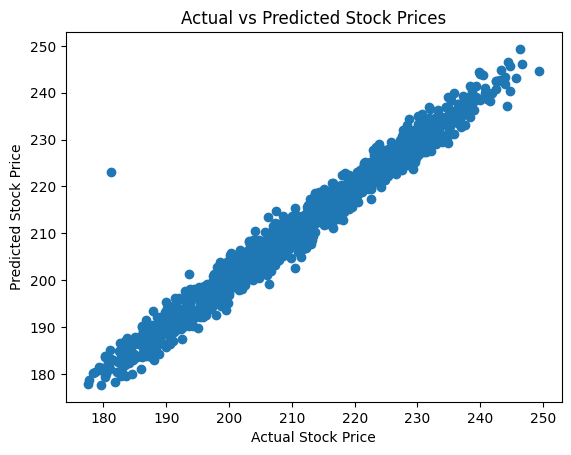

In [ ]:
# Plot comparison between actual and predicted prices
# If points lie close to diagonal line → good predictions

import matplotlib.pyplot as plt

plt.scatter(y_test, predicted_prices)
plt.xlabel("Actual Stock Price")
plt.ylabel("Predicted Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.show()